# Final Dataset Wrangling + Visualizations

## Data Import
After cleaning and transforming the raw data with dbt, we can import the data directly from PostgreSQL.

In [1]:
# Package and library imports

# Import and data wrangling
import pandas as pd
from sqlalchemy import create_engine

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import json
import urllib.request
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Regressions
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
# 1. Setup local Postgres connection string
DATABASE_URL = "postgresql://Kabir@localhost:5432/resilience_gap"

# 2. Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# 3. Load the mart table straight into a Pandas DataFrame
query = "SELECT * FROM dbt_dev.mart_merge"
ess_survey = pd.read_sql(query, con=engine)

print(f"Data loaded. Shape: {ess_survey.shape}")

Data loaded. Shape: (14329, 34)


## Investigating Data Integrity + Additional Cleaning
Here we can investigate data quality, missingness, survey weighting (in dbt we intentionally implemented Winsorization to avoid super heavily weighted individuals skewing models), and grouped sample sizes. We also generate vectors of associated variables, for exampling collapsing the trust variables into one index, as  they  are highly multicollinear and would otherwise skew our models.

In [3]:
# Review columns in data
ess_survey.columns


Index(['nuts1_region', 'country_code', 'nuts_region', 'respondent_id',
       'model_analysis_wt', 'nuts1_gdp_percap_euro_2022',
       'nuts1_unemployment_rate_pct_2022', 'nuts1_net_migration_2022',
       'delta_nuts1_gdp_percap_euro_5yr', 'delta_nuts1_unemployment_rate_5yr',
       'delta_nuts1_net_migration_2yr', 'age', 'gender', 'citizen',
       'identify_ethnic_majority', 'educ_attainment', 'hh_income_comfort',
       'unemp_last_5_years', 'how_religious', 'personal_say_govt', 'eu_role',
       'country_attachment', 'eur_attachment', 'trstprl', 'trstlgl',
       'trst_pol_parties', 'ppltrst', 'immigrants_impact_country',
       'govt_role_income_inequality', 'left_right_alignment', 'sat_life',
       'voting_behavior_manifest', 'intergen_educational_mobility',
       'rw_populist_vote'],
      dtype='str')

In [4]:
def calculate_cronbach_alpha(df, items):
    df_items = ess_survey[items].dropna()
    k = len(items)
    item_variances = df_items.var(ddof=1).sum()
    total_variance = df_items.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - (item_variances / total_variance))
    return alpha

# Test the trust variables
trust_vars = ['trstprl', 'trstlgl', 'trst_pol_parties']
trust_alpha = calculate_cronbach_alpha(ess_survey, trust_vars)

print(f"Cronbach's Alpha for Institutional Trust Matrix: {trust_alpha:.3f}")
if trust_alpha >= 0.70:
    print("👉 Decision: Statistically justified to collapse into a composite index.")
else:
    print("👉 Decision: Low reliability. Keep a single proxy variable.")

ess_survey["trust_index"] = ess_survey[trust_vars].mean(axis=1, skipna=True)

Cronbach's Alpha for Institutional Trust Matrix: 0.804
👉 Decision: Statistically justified to collapse into a composite index.


In [5]:
# 1. Calculate the percentage of missing values per country for every column
missing_report = (
    ess_survey.groupby('country_code')
    .apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    # Drop the grouping column from the axis to avoid redundancy
    .drop(columns=['country_code'], errors='ignore')
)

# 2. Transpose the results so columns are rows, making it incredibly easy to scroll through
missing_report_pivoted = missing_report.T

# 3. Display the full matrix (preventing pandas from clipping rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_report_pivoted.round(2))

country_code                          DE     ES     FR     GR     IT     PL  \
nuts1_region                        0.00   0.00   0.00   0.00   0.00   0.00   
nuts_region                         0.00   0.00   0.00   0.00   0.00   0.00   
respondent_id                       0.00   0.00   0.00   0.00   0.00   0.00   
model_analysis_wt                   0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_gdp_percap_euro_2022          0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_unemployment_rate_pct_2022    0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_net_migration_2022            0.00   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_gdp_percap_euro_5yr     0.00   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_unemployment_rate_5yr   0.00   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_net_migration_2yr       0.00   0.00   0.00   0.00   0.00   0.00   
age                                 0.21   0.49   0.17   0.07   1.05   1.94   
gender                              0.00   0.00   0.

Our target variable, rw_populist_vote, jumps out as the only variable with significant missingness. This is to be expected: not all respondents in the survey are eligible to vote, some are eligible but choose not to vote, some refuse to disclose their vote, some are actual missing data in the survey, and so on. We now observe how many valid respondents we have in each NUTS-1 region.

In [6]:
# Group by country and region to get total sample vs valid voter counts
region_counts = (
    ess_survey.groupby(["country_code", "nuts1_region"])
    .agg(
        sample_size=("respondent_id", "count"),
        valid_voters=("rw_populist_vote", "count")  # count() natively ignores NaNs
    )
    .reset_index()
)

# Sort from highest to lowest valid voter count
region_counts_sorted = region_counts.sort_values(
    by="valid_voters", ascending=False
)

region_counts_sorted

,country_code,nuts1_region,sample_size,valid_voters
34,GR,EL3,923,594
36,GR,EL5,795,539
37,GR,EL6,752,502
51,SE,SE2,538,474
8,DE,DEA,615,424
50,SE,SE1,431,385
38,IT,ITC,883,366
41,IT,ITH,495,265
1,DE,DE2,396,258
19,ES,ES5,447,252


## Statistical Tests

In [7]:
# =====================================================================
# TASK 1: KRUSKAL-WALLIS TEST (Trust Index Across Countries)
# =====================================================================
print("1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION")

# Drop missing rows for this specific test
df_kw = ess_survey.dropna(subset=["trust_index", "country_code"])

# Isolate trust arrays for each of your 7 countries dynamically
country_groups = [
    group["trust_index"].values
    for name, group in df_kw.groupby("country_code")
]

# Run the test
kw_stat, kw_p = stats.kruskal(*country_groups)

print(f"Kruskal-Wallis H-Statistic : {kw_stat:.4f}")
print(f"p-value                    : {kw_p:.4e}")

if kw_p < 0.05:
    print(
        "\n✅ VERDICT: Statistically Significant! The distribution of institutional trust\n"
        "   is fundamentally and structurally different across these European countries.\n"
        "   This mathematically validates splitting data into distinct national regimes."
    )
else:
    print(
        "\n❌ VERDICT: Not Significant. Trust distributions are statistically uniform across nations."
    )

1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION
Kruskal-Wallis H-Statistic : 1517.8236
p-value                    : 0.0000e+00

✅ VERDICT: Statistically Significant! The distribution of institutional trust
   is fundamentally and structurally different across these European countries.
   This mathematically validates splitting data into distinct national regimes.


In [8]:
# =====================================================================
# TASK 2: CHI-SQUARE TEST OF INDEPENDENCE (Country vs. Populist Vote)
# =====================================================================
print("2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING")
print("-" * 60)

# Clean out target missingness to isolate active voters
df_chi = ess_survey.dropna(subset=["rw_populist_vote", "country_code"])

# Generate the cross-tabulation frequency table (Contingency Table)
contingency_table = pd.crosstab(
    df_chi["country_code"], df_chi["rw_populist_vote"]
)

print("Observed Voting Frequencies per Country:")
print(contingency_table)
print("-" * 40)

# Run the Chi-Square test
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic      : {chi2_stat:.4f}")
print(f"Degrees of Freedom (dof)  : {dof}")
print(f"p-value                   : {chi2_p:.4e}")

if chi2_p < 0.05:
    print(
        "\n✅ VERDICT: Statistically Significant! Right-wing populist voting behavior\n"
        "   is heavily dependent on geography. Choosing a populist vs. mainstream party\n"
        "   is not uniformly distributed across borders. This justifies use\n"
        "   of Country Clustered Standard Errors and Fixed Effects."
    )
else:
    print(
        "\n❌ VERDICT: Not Significant. Populist voting rates are statistically independent of country borders."
    )

2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING
------------------------------------------------------------
Observed Voting Frequencies per Country:
rw_populist_vote   0.0  1.0
country_code               
DE                1545   88
ES                1018   74
FR                 705  175
GR                1722  122
IT                 795  446
PL                 600  439
SE                 970  108
----------------------------------------
Chi-Square Statistic      : 1233.4771
Degrees of Freedom (dof)  : 6
p-value                   : 2.7192e-263

✅ VERDICT: Statistically Significant! Right-wing populist voting behavior
   is heavily dependent on geography. Choosing a populist vs. mainstream party
   is not uniformly distributed across borders. This justifies use
   of Country Clustered Standard Errors and Fixed Effects.


## Preliminary Visualizations

In [9]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'legend.title_fontsize': 11
})

In [27]:
# 1. Update helper function to handle exactly 3 significant figures
def to_3_sig_fig(val):
    if val == 0 or val is None:
        return "0.00"
    try:
        # :.3g forces exactly 3 significant figures natively
        return f"{float(f'{val:.3g}')}"
    except (ValueError, TypeError):
        return "N/A"


# 2. Fetch the GeoJSON data
nuts1_geojson_url = (
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
    "NUTS_RG_60M_2021_4326_LEVL_1.geojson"
)
with urllib.request.urlopen(nuts1_geojson_url) as response:
    nuts1_geojson = json.loads(response.read().decode())

# 3. Aggregate metrics and create 3 significant figure string overlays
regional_shocks = (
    ess_survey.groupby("nuts1_region")
    .agg(
        {
            "delta_nuts1_gdp_percap_euro_5yr": "mean",
            "delta_nuts1_net_migration_2yr": "mean",
        }
    )
    .reset_index()
)

regional_shocks["gdp_shk_str"] = (
    regional_shocks["delta_nuts1_gdp_percap_euro_5yr"].apply(to_3_sig_fig)
)
regional_shocks["mig_shk_str"] = (
    regional_shocks["delta_nuts1_net_migration_2yr"].apply(to_3_sig_fig)
)

# 4. Initialize a 1-row, 2-column subplots grid with geographical types
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "5-Yr GDP per Capita Delta (€)<br>(Red = Economic Decline)",
        "2-Yr Net Migration Delta (per 1k)<br>(Blue = Outflow | Red = Influx Acceleration)",
    ),
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
)

# 5. Build Panel A: GDP per Capita Shock (Diverging Scale: Negative growth is Red)
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=regional_shocks["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=regional_shocks["delta_nuts1_gdp_percap_euro_5yr"],
        colorscale="RdBu",  # Negative values map to Red, Positive map to Blue
        zmid=0.0,
        colorbar=dict(
            title="GDP Δ (€)",
            x=0.45,         # Anchors legend perfectly in the center gutter between maps
            xanchor="left",
            len=0.75,
            y=0.5
        ),
        customdata=regional_shocks[
            ["nuts1_region", "gdp_shk_str", "mig_shk_str"]
        ],
        hovertemplate=(
            "<b>Region: %{customdata[0]}</b><br>"
            "5-Yr GDP Delta: €%{customdata[1]}<br>"
            "2-Yr Migration Delta: %{customdata[2]}<br>"
            "2022 Unemployment Base: %{customdata[3]}%"
        ),
    ),
    row=1,
    col=1,
)

# 6. Build Panel B: Migration Shock (Diverging Scale: Transition from Blue to Red)
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=regional_shocks["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=regional_shocks["delta_nuts1_net_migration_2yr"],
        colorscale="RdBu_r", # Reversed RdBu targets Blue for drops and Red for growth spikes
        zmid=0.0,
        colorbar=dict(
            title="Migration Δ",
            x=1.02,         # Anchors legend cleanly on the right hand margin
            xanchor="left",
            len=0.75,
            y=0.5
        ),
        customdata=regional_shocks[
            ["nuts1_region", "gdp_shk_str", "mig_shk_str"]
        ],
        hovertemplate=(
            "<b>Region: %{customdata[0]}</b><br>"
            "5-Yr GDP Delta: €%{customdata[1]}<br>"
            "2-Yr Migration Delta: %{customdata[2]}<br>"
            "2022 Unemployment Base: %{customdata[3]}%"
        ),
    ),
    row=1,
    col=2,
)

# 7. Configure shared continental baseline views for both maps simultaneously
geo_layout = dict(
    scope="europe",
    showcountries=True,
    countrycolor="LightGrey",
    showlakes=False,
    projection_type="transverse mercator",
    center={"lat": 52.0, "lon": 10.0},
)

fig.update_layout(
    title_text="The Macro-Regional Shock Matrix: Twin-Axis Structural Diagnostics",
    geo=geo_layout,
    geo2=geo_layout,
    margin={"r": 50, "t": 100, "l": 50, "b": 0},
    height=550,
    width=1300,)  # Gracefully holds both map panels side-by-side

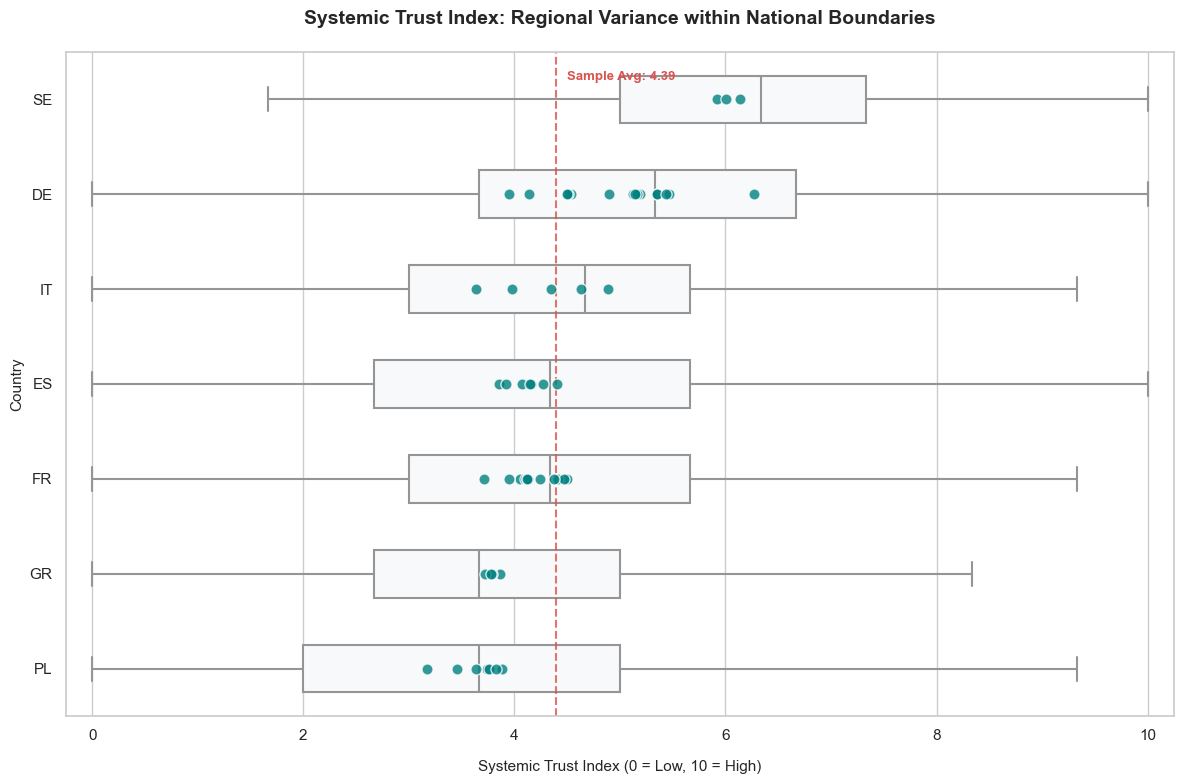

In [11]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Pre-calculate country medians to sort the categories beautifully
country_order = (
    ess_survey.groupby("country_code")["trust_index"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 2. Draw a clean, minimalist horizontal boxplot for the national baseline
sns.boxplot(
    data=ess_survey,
    y="country_code",
    x="trust_index",
    order=country_order,
    color="#f8f9fa",      # Subtle neutral background for the national spread
    width=0.5,
    linewidth=1.5,
    showfliers=False,     # Hide individual respondent outliers to keep focus on regions
)

# 3. Layer regional averages as distinct, punchy points on top
# This maps the variance between NUTS1 regions explicitly
region_means = (
    ess_survey.groupby(["country_code", "nuts1_region"])["trust_index"]
    .mean()
    .reset_index()
)

sns.stripplot(
    data=region_means,
    y="country_code",
    x="trust_index",
    order=country_order,
    size=8,
    color="teal",
    alpha=0.8,
    linewidth=1,
    edgecolor="white",
    jitter=False,         # Keeping them aligned linearly lets you spot the spread easily
)

# 4. Polish labels and boundaries
plt.title(
    "Systemic Trust Index: Regional Variance within National Boundaries",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Systemic Trust Index (0 = Low, 10 = High)", fontsize=11, labelpad=12)
plt.ylabel("Country", fontsize=11)
plt.xlim(-0.25, 10.25)

# Add an explicit overall panel mean line for diagnostic grounding
overall_mean = ess_survey["trust_index"].mean()
plt.axvline(
    overall_mean, color="#d9534f", linestyle="--", linewidth=1.5, alpha=0.8
)
plt.text(
    overall_mean + 0.1,
    -0.2,
    f"Sample Avg: {overall_mean:.2f}",
    color="#d9534f",
    weight="bold",
    fontsize=9.5,
)

plt.tight_layout()

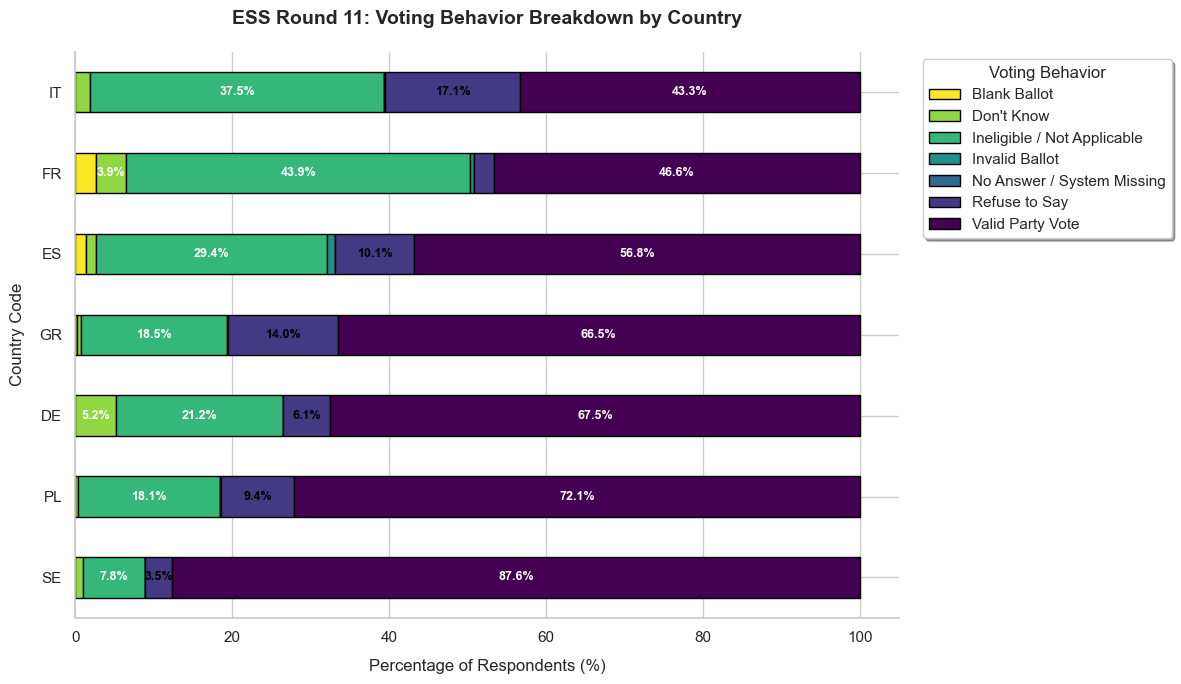

In [12]:
# 1. Calculate percentages of voting behavior by country
# This normalizes the row counts so we can see relative proportions
cross_tab = pd.crosstab(
    ess_survey["country_code"],
    ess_survey["voting_behavior_manifest"],
    normalize="index",  # Calculates percentages per row (country)
) * 100

# 2. Sort the countries by a specific category to make the visual cleaner
# Sorting by 'Valid Party Vote' gives the chart a nice visual gradient
cross_tab = cross_tab.sort_values(by="Valid Party Vote", ascending=False)

# 3. Plotting the 100% Stacked Bar Chart
ax = cross_tab.plot(
    kind="barh", stacked=True, figsize=(12, 7), cmap="viridis_r", edgecolor="black"
)

# 4. Styling and Aesthetics
sns.despine()  # Cleans up the top and right borders
plt.title(
    "ESS Round 11: Voting Behavior Breakdown by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Percentage of Respondents (%)", fontsize=12, labelpad=10)
plt.ylabel("Country Code", fontsize=12, labelpad=10)

# Move the legend outside so it doesn't overlap the bars
plt.legend(
    title="Voting Behavior",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
)

# 5. Add percentage labels directly onto the bars for scannability
# (Only adds labels for blocks larger than 3% to avoid messy overlap)
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # Skip labeling tiny slices (like system slips)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(
            x,
            y,
            f"{width:.1f}%",
            ha="center",
            va="center",
            color="white" if p.get_facecolor()[2] < 0.5 else "black",
            fontsize=9,
            weight="bold",
        )

plt.tight_layout()
plt.show()

## Regressions
To test for potential multicollinearity across our individual and macro-regional variables, Variance Inflation Factors (VIF) were calculated across all independent variables. All core individual-level attitudinal and socioeconomic controls display highly robust independence, with VIF scores resting well below 2.0. Mild elevation was observed in the 5-year regional unemployment shock metric (VIF = 7.95) and the Greek national baseline indicator (VIF = 9.26). This covariance is a natural mathematical reflection of nested macroeconomic variations across Southern Europe. Because all features remain safely below the conservative threshold of 10.0, and our regression specifications utilize country-clustered standard errors, the model is mathematically stable and free from problematic multicollinearity.

In [13]:

# =====================================================================
# 1. PREPARE THE DESIGN MATRIX (X)
# =====================================================================
# Select ONLY the independent variables going into formula
vif_features = [
    "trust_index",
    "immigrants_impact_country",
    "left_right_alignment",
    "educ_attainment",
    "intergen_educational_mobility",
    "hh_income_comfort",
    "unemp_last_5_years",
    "age",
    "gender",
    "delta_nuts1_gdp_percap_euro_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",
    "country_code" # Categorical - must be encoded
]
# Drop missing rows across these specific features to align with model universe
df_vif_prep = ess_survey[vif_features].dropna().copy()

# Convert categorical country_code into 0/1 numeric dummy columns 
# (drop_first=True mirrors exactly how statsmodels treats C(country_code) references)
X = pd.get_dummies(df_vif_prep, columns=["country_code"], drop_first=True, dtype=int)

# CRITICAL STEP: statsmodels VIF requires an explicit intercept/constant column
X = sm.add_constant(X)

# =====================================================================
# 2. CALCULATE VARIANCE INFLATION FACTORS
# =====================================================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Filter out the constant row so we focus entirely on our variables
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print("═" * 60)
print("VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS")
print("═" * 60)
print(vif_data.to_string(index=False, formatters={"VIF": "{:.2f}".format}))

════════════════════════════════════════════════════════════
VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
════════════════════════════════════════════════════════════
                          Feature   VIF
                  country_code_GR 11.35
delta_nuts1_unemployment_rate_5yr  6.90
                  country_code_ES  3.93
  delta_nuts1_gdp_percap_euro_5yr  3.17
                  country_code_IT  2.93
                  country_code_FR  2.54
                  country_code_PL  2.49
    delta_nuts1_net_migration_2yr  2.35
                  country_code_SE  1.94
                  educ_attainment  1.90
    intergen_educational_mobility  1.71
                hh_income_comfort  1.40
        immigrants_impact_country  1.34
                              age  1.28
                      trust_index  1.27
             left_right_alignment  1.14
               unemp_last_5_years  1.07
                           gender  1.01


### Macro level model
Interpretation: After testing, the macro model is not particularly compelling, as it shows that between-country variation explains most of the patterns. Further, the coefficients reflect that perhaps the 5 year time period is not long enough to capture a true shift in voting attitudes, rather a longer-term 'stickier' institutional setting. Finally, the explanatory power is limited by the fact that almost all regions experienced reduced unemployment rates and increased GDP over this time period. It is kept here for transparency to show that it was tested.

In [165]:
macro_cols = [
    "rw_populist_vote",
    "model_analysis_wt",

    "delta_nuts1_gdp_percap_euro_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",

    "country_code",
    "nuts1_region"
]

# Clean sample
df_macro = ess_survey[macro_cols].dropna().copy()

# Standardise macro variables (single, consistent step)
macro_vars = [
    "delta_nuts1_gdp_percap_euro_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr"
]

scaler = StandardScaler()
df_macro[macro_vars] = scaler.fit_transform(df_macro[macro_vars])

# Model specification (fixed syntax)
macro_formula = (
    "rw_populist_vote ~ "
    "delta_nuts1_gdp_percap_euro_5yr + "
    "delta_nuts1_unemployment_rate_5yr + "
    "delta_nuts1_net_migration_2yr + "
    "C(country_code)"
)

macro_logit_model = smf.glm(
    formula=macro_formula,
    data=df_macro,
    family=sm.families.Binomial(),
    var_weights=df_macro["model_analysis_wt"]
).fit()

print(macro_logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8807
Model:                            GLM   Df Residuals:                     8797
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3353.5
Date:                Mon, 15 Jun 2026   Deviance:                       6707.1
Time:                        23:23:10   Pearson chi2:                 8.50e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1170
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Individual level model (with mobility)

In [15]:
# Individual model version 1
# Isolate individual-level features 
model_cols = [
    "rw_populist_vote",  # Target (Dropped NaNs natively restrict to active voters)
    "model_analysis_wt", # Weighting variable
    "trust_index",  # Replaced individual trst_pol_parties
    "immigrants_impact_country", 
    "intergen_educational_mobility",
    "educ_attainment",
    "hh_income_comfort",
    "unemp_last_5_years",
    "gender",
    "age",
    "country_code",  # Used for baseline country fixed-effects
]


# Create a clean modeling matrix free of missing values
df_logit = ess_survey[model_cols].dropna()

# ==========================================
# 2. FIT THE FIXED-EFFECTS LOGISTIC MODEL
# ==========================================

logit_model_mobility = smf.glm(
    formula="rw_populist_vote ~ trust_index + immigrants_impact_country + educ_attainment + intergen_educational_mobility + hh_income_comfort + unemp_last_5_years + gender + age + C(country_code)",
    data=df_logit,
    family=sm.families.Binomial(),
    freq_weights=df_logit["model_analysis_wt"] # <-- CRITICAL ADDITION
).fit()
# Print the final baseline parameter diagnostics
print(logit_model_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8319
Model:                            GLM   Df Residuals:                  7985.93
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2749.7
Date:                Tue, 16 Jun 2026   Deviance:                       5499.4
Time:                        00:49:02   Pearson chi2:                 8.36e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1893
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

 With a heavy heart, I am dropping the intergenerational mobility variable (intergenerational education deviation) from the main specification. Although it was designed to capture whether individuals are above or below the educational level of their parents, in practice it is highly correlated with education and does not materially improve model fit or change the main conclusions.

 When included, it produces a small but significant positive coefficient, but the implications are ambiguous. Given that the goal of the project is to explain voting behaviour in a way that is interpretable and accessible, especially for a non-technical audience, the added complexity of this variable outweighs its marginal explanatory benefit.

 For this reason, the main model focuses on absolute education (educ_attainment) as the more straightforward and interpretable measure of socioeconomic position, while mobility is included above for robustness checks and exploratory analysis.

In [82]:
ess_survey["intergen_educational_mobility"].isna().sum() # 679, this is meaningful and likely non-random
ess_survey["educ_attainment"].isna().sum() # 78

# Verifying relationship between educational attainment and intergenerational mobility, danger of multicollinearity
df_logit["intergen_educational_mobility"].describe()

df_logit[["educ_attainment",
          "intergen_educational_mobility"]].corr()

,educ_attainment,intergen_educational_mobility
educ_attainment,1.000000,0.458428
intergen_educational_mobility,0.458428,1.000000


### No mobility

In [16]:
# No mobility

df_logit = ess_survey.dropna(subset=[
    "rw_populist_vote",
    "trust_index",
    "immigrants_impact_country",
    "educ_attainment",
    "gender",
    "age",
    "country_code"
])

# Intercept is DE
# Gender: 0 is male, 1 is female
logit_model_no_mobility = smf.glm(
    formula="""
        rw_populist_vote ~
        trust_index +
        immigrants_impact_country +
        educ_attainment +
        gender +
        age +
        C(country_code)
    """,
    data=df_logit,
    family=sm.families.Binomial(),
    var_weights=df_logit["model_analysis_wt"]
).fit()

print(logit_model_no_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8616
Model:                            GLM   Df Residuals:                     8604
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2889.2
Date:                Tue, 16 Jun 2026   Deviance:                       5778.5
Time:                        00:49:24   Pearson chi2:                 8.64e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1891
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**Individual-Level Predictors of Right-Wing Populist Voting: Model Results**

The binomial logistic regression model estimates the association between individual-level attitudinal, socioeconomic, and demographic characteristics and the probability of voting for a right-wing populist party, with country fixed effects setting the baseline level of support in each national context. The pseudo R-squared of 0.19 indicates a solid and credible fit for this type of cross-sectional analysis. All substantive predictors attain statistical significance at conventional thresholds, and the direction of effects is consistent throughout with the theoretical expectations motivating the analysis.

The strongest predictor is immigration attitudes. Respondents who view immigration's impact on their country more negatively are substantially more likely to vote for right-wing populist parties — this effect is larger than any other individual-level variable in the model and holds firmly after controlling for all other factors. Each one-unit increase toward a more positive assessment of immigration's effect on the country is associated with a reduction of approximately 28.5% in the odds of populist voting, holding all other variables constant. This aligns with the view that perceived cultural and demographic change, rather than economic hardship alone, is the primary engine of populist support.

Institutional trust is the second most important predictor. Each one-unit increase in the composite trust score is associated with a reduction of approximately 10.2% in the odds of populist voting, consistent with the idea that anti-establishment behavior is partly an expression of alienation from the political system rather than a straightforward economic response.

Educational attainment also shows a clear and stable negative association with populist voting, supporting the hypothesis that education acts as a partial buffer against anti-establishment political behavior. Age and gender are smaller but reliable effects — younger respondents and men are modestly more likely to vote populist.

Country differences remain large even after accounting for all individual-level factors. This suggests that national political histories and party systems shape the overall level of populist voting in ways that individual attitudes alone cannot explain.

The results indicate that right-wing populist voting in this sample is driven primarily by attitudinal and perceptual factors — most notably the perceived cultural and social impact of immigration and the degree of trust extended to political institutions — rather than by objective socioeconomic position or short-term economic circumstances. This pattern is more consistent with cultural and institutional accounts of populist support than with purely economic ones, though the significant educational attainment effect suggests that structural human capital factors retain an independent and non-trivial role in moderating populist vote propensity.

## K-Means Clustering of Region Types

In [19]:
df_clean = ess_survey.dropna(subset=["model_analysis_wt", "nuts1_region"]).copy()

def weighted_mean(group, col):
    x, w = group[col], group["model_analysis_wt"]
    m = x.notna()
    return np.average(x[m], weights=w[m]) if m.sum() > 0 else np.nan

regional_data = []

for name, g in df_clean.groupby("nuts1_region"):

    if len(g) < 50:
        continue

    regional_data.append({
        "nuts1_region": name,
        "country_code": g["country_code"].iloc[0],
        "sample_size": len(g),

        # STRUCTURAL ONLY
        "gdp": g["nuts1_gdp_percap_euro_2022"].iloc[0],
        "unemployment": g["nuts1_unemployment_rate_pct_2022"].iloc[0],
        "migration": g["nuts1_net_migration_2022"].iloc[0],
    })

df_regions = pd.DataFrame(regional_data).dropna()


cluster_features = ["gdp", "unemployment", "migration"]

X = StandardScaler().fit_transform(df_regions[cluster_features])


# K=5 confirmed as optimal via silhouette analysis
kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init=20)
df_regions["cluster_k5"] = kmeans_k5.fit_predict(X)

# Merge cluster assignments onto individual-level data
df_with_clusters = df_clean.merge(
    df_regions[["nuts1_region", "cluster_k5"]],
    on="nuts1_region",
    how="left"
)

### Testing optimal number of groups

In [20]:
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels)) # 5 is highest, but 4 perhaps more interpretable

def run_kmeans(k):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    return km.fit_predict(X)

#df_regions["cluster_k4"] = run_kmeans(4)
df_regions["cluster_k5"] = run_kmeans(5)

df_with_clusters = df_clean.merge(
    df_regions[["nuts1_region", "cluster_k5"]],
    on="nuts1_region",
    how="left"
)

features = ["gdp", "unemployment", "migration"]

def build_structural_profile(df, cluster_col):
    profile = df.groupby(cluster_col)[features].mean()
    profile_z = (profile - profile.mean()) / profile.std()
    return profile, profile_z

overlay_vars = [
    "rw_populist_vote",
    "trust_index",
    "educ_attainment",
    "immigrants_impact_country"
]

def build_behavioural_profile(df, cluster_col):
    records = []
    for cluster_id, group in df.groupby(cluster_col):
        row = {"cluster": cluster_id}
        for var in overlay_vars:
            row[var] = weighted_mean(group, var)
        records.append(row)
    profile = pd.DataFrame(records).set_index("cluster")
    profile_z = (profile - profile.mean()) / profile.std()
    return profile, profile_z

# Structural profile: macro constants, unweighted mean across regions is valid
# (gdp, unemployment, migration are region-level constants, not respondent-level)
struct_5, struct_5_z = build_structural_profile(df_regions, "cluster_k5")

# Behavioural overlay: respondent-level variables, weighted aggregation preferred
behav_5, behav_5_z = build_behavioural_profile(df_with_clusters, "cluster_k5")


print("\n=== K=5 STRUCTURAL ===\n")
print(struct_5_z.round(2))

print("\n=== K=5 BEHAVIOURAL ===\n")
print(behav_5_z.round(2))

df_regions["cluster_k5"].value_counts().sort_index()

2 0.37308210996548047
3 0.3626594221707658
4 0.35034811292857504
5 0.4366907132641342
6 0.3904508971509014
7 0.3888508467300225

=== K=5 STRUCTURAL ===

             gdp  unemployment  migration
cluster_k5                               
0           0.50         -0.46       0.37
1          -0.23          1.13       1.51
2           1.47         -0.73      -1.15
3          -1.01         -0.97      -0.41
4          -0.72          1.02      -0.32

=== K=5 BEHAVIOURAL ===

         rw_populist_vote  trust_index  educ_attainment  \
cluster                                                   
0.0                  0.05         0.99             0.06   
1.0                 -0.69        -0.29            -0.86   
2.0                 -0.69         1.11             0.44   
3.0                  1.70        -1.09             1.41   
4.0                 -0.38        -0.72            -1.04   

         immigrants_impact_country  
cluster                             
0.0                          -0.20  
1.

cluster_k5
0    24
1     7
2     5
3     7
4     7
Name: count, dtype: int64

The clustering process began with a range of specifications (k=2–6), where silhouette scores indicated progressively improving separation up to k=5 before declining, suggesting that five clusters represented the most coherent partition of the structural feature space. The five-cluster solution preserved overall structure while isolating a smaller but substantively distinct high-populism, low-trust regional niche that was otherwise absorbed in the coarser specification. On this basis, k=5 was selected as the preferred model due to its stronger statistical separation and improved substantive resolution, particularly in capturing heterogeneity at the lower-trust, higher-populism tail of the distribution. The resulting five clusters can be interpreted as: (1) core affluent low-unemployment regions, (2) stable intermediate regions with moderate structural conditions, (3) migration-intensive dynamic regions, (4) structurally weaker high-unemployment regions, and (5) a distinct low-trust, high-populism peripheral niche.

In [41]:
# =========================================================
# 1. CLUSTER LABELS + COLORS
# =========================================================
cluster_labels = {
    0: "Moderate Baseline",
    1: "High Migration",
    2: "Affluent High-Trust Core",
    3: "Low-Trust Populist Strongholds",
    4: "Economically Stressed Periphery"
}

cluster_colors = {
    0: "#3920b9",
    1: "#a9c03b",
    2: "#d95f02",
    3: "#b30f2d",
    4: "#1b9e77"
}

# =========================================================
# 2. CLUSTER DATA PREP
# =========================================================
cluster_map = df_regions[["nuts1_region", "cluster_k5"]].copy()
cluster_map["cluster_k5"] = cluster_map["cluster_k5"].astype(int)

df_plot = df_clean.merge(
    cluster_map,
    on="nuts1_region",
    how="left"
)

# =========================================================
# 3. POPULISM INTENSITY AT REGION LEVEL
# =========================================================
pop_map = (
    df_plot.groupby("nuts1_region")["rw_populist_vote"]
    .mean()
    .reset_index()
)

# =========================================================
# 5. SUBPLOTS
# =========================================================
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=(
        "Structural Regional Typology (k=5)",
        "Populist Vote Intensity"
    )
)

# =========================================================================
# 6. LEFT: STRUCTURAL CLUSTERS (Legend Placed in Center Gutter)
# =========================================================================
for cid in sorted(cluster_map["cluster_k5"].dropna().unique()):
    sub = cluster_map[cluster_map["cluster_k5"] == cid]

    fig.add_trace(
        go.Choropleth(
            geojson=nuts1_geojson,
            locations=sub["nuts1_region"],
            featureidkey="properties.NUTS_ID",
            z=[cid] * len(sub),
            name=cluster_labels[cid],
            colorscale=[[0, cluster_colors[cid]], [1, cluster_colors[cid]]],
            showscale=False,
            marker_line_width=0.3,
            hovertemplate=(
                "<b>%{location}</b><br>"
                "Type: " + cluster_labels[cid] + "<extra></extra>"
            ),
            showlegend=True
        ),
        row=1,
        col=1
    )

# =========================================================================
# 7. RIGHT: POPULIST VOTE INTENSITY (Colorbar Moved to Far Right Margin)
# =========================================================================
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=pop_map["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=pop_map["rw_populist_vote"],
        colorscale="Reds",
        zmin=0,
        zmax=pop_map["rw_populist_vote"].max(),
        # FIXED: Move continuous colorbar to the far right edge of the entire layout
        colorbar=dict(
            title="Populist Vote Share",
            x=1.02,
            xanchor="left",
            len=0.6,
            y=0.5
        ),
        hovertemplate=(
            "<b>%{location}</b><br>"
            "Populist Vote: %{z:.2%}<extra></extra>"
        ),
        showscale=True
    ),
    row=1,
    col=2
)

# =========================================================================
# 8. LAYOUT (Discrete Legend Moved to Center Gutter)
# =========================================================================
geo_style = dict(
    scope="europe",
    showcountries=True,
    countrycolor="LightGrey",
    projection_type="transverse mercator",
    center={"lat": 52.0, "lon": 10.0},
)

fig.update_layout(
    title_text="Structural Typology vs Rightwing Populist Vote Intensity (NUTS1 Europe)",
    geo=geo_style,
    geo2=geo_style,
    # FIXED: Lock the categorical legend inside the map-separating gutter (x=0.45)
    legend=dict(
        title="Structural Types",
        x=0.45,
        y=0.5,
        xanchor="center",
        yanchor="middle",
        font=dict(size=9.5)
    ),
    # Expand the right margin to accommodate the color bar cleanly
    margin={"r": 120, "t": 100, "l": 20, "b": 20},
    height=650,
    width=1400  # Slighly widened to give the center gutter text breathing room
)

fig.show()

Cluster 0 (Intermediate Baseline Regions) is structurally and behaviourally the closest to the mean on almost every dimension, which makes it analytically the least distinctive cluster.

Cluster 1 (Migration-Pressure Regions) presents a theoretically interesting profile. It has the highest migration delta and the highest unemployment delta simultaneously, yet its behavioural overlay shows below-average populist voting and below-average trust. The positive immigrants_impact_country score (1.04 standard deviations above mean) is notable — residents of high-migration-pressure regions perceive immigration's impact more positively than average, which cuts against the naive cultural threat hypothesis. This is a counterintuitive result that complicates simple economic anxiety narratives.

Cluster 2 (Affluent High-Trust Core) and Cluster 3 (Low-Trust Populist Strongholds) represent the sharpest structural contrast and the clearest validation of the buffer hypothesis. Cluster 2 is high GDP, low unemployment, low migration, and produces the lowest populist vote share and highest trust in the behavioural overlay. Cluster 3 is low GDP, low unemployment — interestingly — but high populist vote share and the lowest trust score of any cluster. This is a substantively important finding: Cluster 3 is not characterised by acute labour market stress but by structural economic stagnation combined with institutional alienation. This pattern is more consistent with the Inglehart/Norris cultural displacement thesis than with the Kriesi economic shock thesis.

Cluster 4 (Economically Stressed Periphery) has below-average GDP and above-average unemployment but the most negative immigrants_impact_country score of any cluster (-1.64). This dissociation — economic stress without elevated migration pressure, yet the most hostile immigration attitudes — supports the Guriev/Papaioannou framework's argument that cultural threat perception and economic anxiety are separable and do not always co-occur in the expected configuration.

In [30]:
# =====================================================================
# ASSET 1: THE REGIONAL DATA FILE (1 row per NUTS-1 Region)
# =====================================================================
# 1. Gather true macro deltas and raw base values from survey rows
regional_macro = ess_survey.groupby("nuts1_region").agg({
    "delta_nuts1_gdp_percap_euro_5yr": "mean",
    "delta_nuts1_net_migration_2yr": "mean",
    "nuts1_unemployment_rate_pct_2022": "mean"
}).reset_index()

# 2. Merge macro baselines with cluster identities from your regional dataframe
df_regional_dashboard = df_regions[["nuts1_region", "country_code", "sample_size", "gdp", "unemployment", "migration", "cluster_k5"]].copy()
df_regional_dashboard = df_regional_dashboard.merge(regional_macro, on="nuts1_region", how="left")

# Clean text case alignments
df_regional_dashboard["nuts1_region"] = df_regional_dashboard["nuts1_region"].astype(str).str.strip().str.upper()

# Export Asset 1
df_regional_dashboard.to_csv("streamlit/dashboard_regional_data.csv", index=False)


# =====================================================================
# ASSET 2: THE INDIVIDUAL DATA FILE (1 row per Survey Respondent)
# =====================================================================
# Keep only the rows and variables required for individual distributions and model summaries
individual_vars = [
    "nuts1_region", "country_code", "trust_index", "voting_behavior_manifest",
    "rw_populist_vote", "immigrants_impact_country", "educ_attainment", "gender", "age"
]

# Pull clean individual records that match active clusters
df_individual_dashboard = df_with_clusters[individual_vars].copy()

# Map the cluster ID back to individuals so you can filter attitudes by cluster type
cluster_mapping = df_regions.set_index("nuts1_region")["cluster_k5"].to_dict()
df_individual_dashboard["cluster_k5"] = df_individual_dashboard["nuts1_region"].map(cluster_mapping)

# Clean text case alignments
df_individual_dashboard["nuts1_region"] = df_individual_dashboard["nuts1_region"].astype(str).str.strip().str.upper()

# Export Asset 2
df_individual_dashboard.to_csv("streamlit/dashboard_individual_data.csv", index=False)

In [40]:
html_summary = logit_model_no_mobility.summary().as_html()

with open(
    "streamlit/logit_summary.html",
    "w"
) as f:
    f.write(html_summary)